In [1]:
import time
import pandas as pd
import json
import numpy as np
from datetime import datetime
from datetime import timezone
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
from matplotlib.colors import ListedColormap
import numpy as np
# import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
def remove_specific_cycles(data_loader, indices_to_remove):
    """
    Excludes specific indices from every key in the dataset.
    indices_to_remove: list of integers (e.g., [1, 3, 6])
    """
    cleaned_data = {}
    
    for key in data_loader.files:
        original_list = list(data_loader[key])
        # Keep only the items whose index is NOT in our 'remove' list
        cleaned_data[key] = [
            cycle for i, cycle in enumerate(original_list) 
            if i not in indices_to_remove
        ]
        
    return cleaned_data

def get_cycle_stats(data_source, param_prefix, leg, norm_points=100):
    """
    Interpolates cycles for a specific leg/parameter and calculates mean/std.
    """
    key = f'{param_prefix}_{leg}'
    if key not in data_source:
        return None, None, None

    raw_cycles = data_source[key]
    normalized_list = []
    

    for j, cycle in enumerate(raw_cycles):
            
        x_old = np.linspace(0, 100, len(cycle))
        x_new = np.linspace(0, 100, norm_points)
        norm_cycle = np.interp(x_new, x_old, cycle)
        normalized_list.append(norm_cycle)
    
    if not normalized_list:
        return None, None, None

    norm_matrix = np.array(normalized_list)
    mean_vals = np.mean(norm_matrix, axis=0)
    std_vals = np.std(norm_matrix, axis=0)
    x_axis = np.linspace(0, 100, norm_points)

    return x_axis, mean_vals, std_vals

In [3]:
def load_cycles_from_npz(filename):
    """
    Loads a flattened .npz file and reconstructs the nested dictionary.
    """
    data = np.load(filename)
    reconstructed = {}
    
    for key in data.files:
        # Split the key (e.g., 'rough_foot_force')
        # We use rsplit once from the right to handle sensor names with underscores
        parts = key.split('_', 1) 
        if len(parts) < 2: continue
        
        terrain, sensor = parts[0], parts[1]
        
        if terrain not in reconstructed:
            reconstructed[terrain] = {}
        
        # Convert the (N, 100, F) array back into a list of (100, F) arrays
        # This makes it compatible with your existing segment_all_trials output
        reconstructed[terrain][sensor] = [cycle for cycle in data[key]]
        
    print(f"Loaded {len(reconstructed)} terrains from {filename}")
    return reconstructed

# --- Execution ---
dataset = load_cycles_from_npz('walking_terrain_datasets.npz')

Loaded 3 terrains from walking_terrain_datasets.npz


In [4]:
name_joints = ['FR_J1', 'FR_J2', 'FR_J3', 'FR_J4', 
 'BR_J1', 'BR_J2', 'BR_J3', 'BR_J4', 
 'FL_J1', 'FL_J2', 'FL_J3', 'FL_J4', 
 'BL_J1', 'BL_J2', 'BL_J3', 'BL_J4']

name_legs = ['FR', 'BR', 'FL', 'BL']

# Plot show

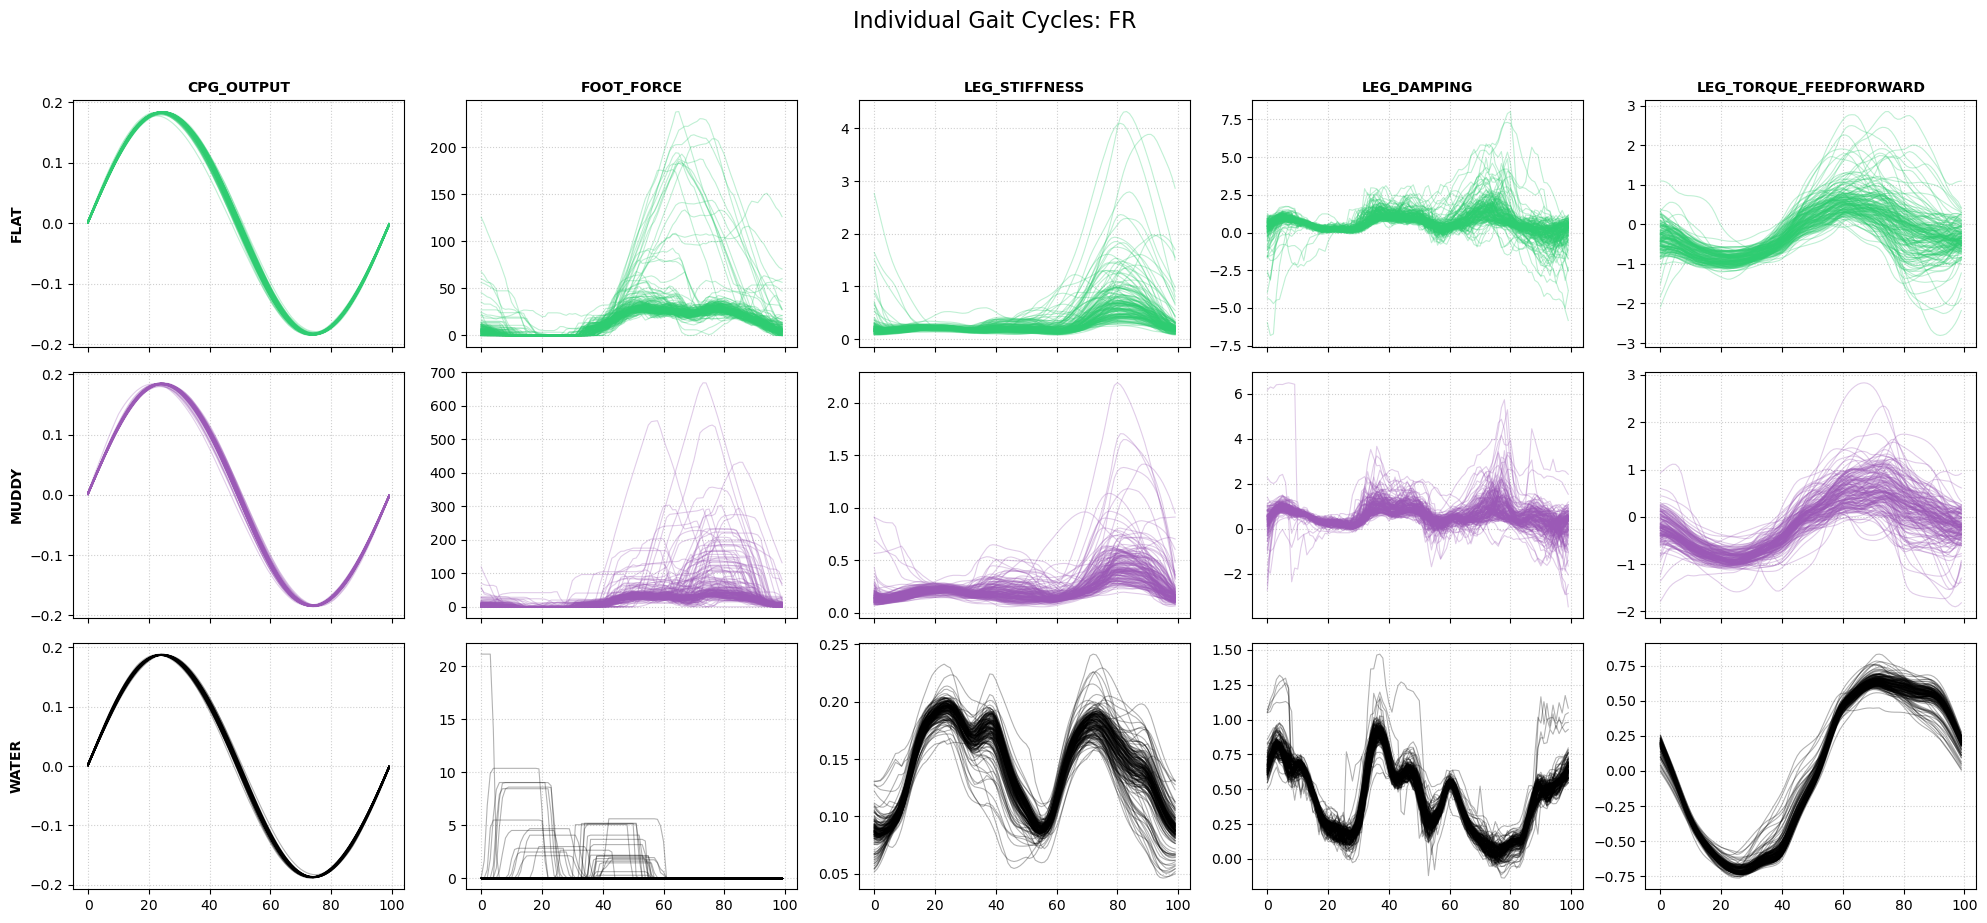

In [35]:
def plot_all_individual_cycles(cycle_results, sensor_list, feature_idx=0):
    """
    Plots every single cycle for every terrain to see the raw distribution.
    """
    terrains = list(cycle_results.keys())
    num_terrains = len(terrains)
    num_sensors = len(sensor_list)
    
    colors = {
        'flat': '#2ecc71', 'rough': '#e74c3c', 'sponge': '#3498db', 
        'sandy': '#f1c40f', 'muddy': '#9b59b6'
    }

    # Use a dynamic title based on the index
    # We try to find the name from the global scope, otherwise use the index number
    try:
        # Check if the first sensor in the list is a leg or joint sensor
        is_joint = 'joint' in sensor_list[0]
        feature_name = name_joints[feature_idx] if is_joint else name_legs[feature_idx]
    except (NameError, IndexError):
        feature_name = f"Index {feature_idx}"

    fig, axes = plt.subplots(num_terrains, num_sensors, 
                               figsize=(4 * num_sensors, 3 * num_terrains), 
                               sharex=True, squeeze=False) # squeeze=False keeps axes 2D (rows, cols)

    for t_idx, terrain in enumerate(terrains):
        for s_idx, sensor in enumerate(sensor_list):
            ax = axes[t_idx, s_idx]
            
            # Use .get() to avoid KeyError if a sensor is missing for a terrain
            cycles = cycle_results.get(terrain, {}).get(sensor, [])
            
            if not cycles or len(cycles) == 0:
                ax.text(0.5, 0.5, 'No Data', ha='center', transform=ax.transAxes)
                continue
            
            color = colors.get(terrain, 'black')
            
            # Plot every single cycle
            for cycle in cycles:
                # cycle shape is (100, num_features)
                ax.plot(cycle[:, feature_idx], color=color, alpha=0.3, linewidth=0.8)
            
            # Formatting titles only for the top row
            if t_idx == 0:
                ax.set_title(f"{sensor.upper()}", fontsize=10, fontweight='bold')
            
            # Formatting labels only for the first column
            if s_idx == 0:
                ax.set_ylabel(f"{terrain.upper()}", fontsize=10, fontweight='bold')
            
            ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f"Individual Gait Cycles: {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# --- Execution ---
sensors_to_plot = ['cpg_output', 'foot_force', 'leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
plot_all_individual_cycles(dataset, sensors_to_plot, feature_idx=0)

In [6]:

def plot_all_sensors_comparison(cycle_results, sensor_list, feature_index=0, feature_name="Leg 0"):
    """
    Creates a vertical stack of subplots comparing multiple sensors across all terrains.
    """
    terrains = list(cycle_results.keys())
    colors = {'flat': 'green', 'rough': 'red', 'water': 'blue', 'sandy': 'orange', 'muddy': 'brown'}
    
    num_sensors = len(sensor_list)
    fig, axes = plt.subplots(num_sensors, 1, figsize=(5, 3 * num_sensors), sharex=True)
    
    # Ensure axes is iterable even if there's only one sensor
    if num_sensors == 1:
        axes = [axes]

    for i, sensor_name in enumerate(sensor_list):
        ax = axes[i]
        
        for terrain in terrains:
            # Check if data exists for this terrain/sensor combo
            cycles = cycle_results.get(terrain, {}).get(sensor_name, [])
            if not cycles:
                continue
                
            data_stack = np.stack(cycles)
            feature_data = data_stack[:, :, feature_index]
            
            mean_traj = np.mean(feature_data, axis=0)
            std_traj = np.std(feature_data, axis=0)
            
            x = np.arange(100)
            color = colors.get(terrain, 'black')
            
            ax.plot(x, mean_traj, label=terrain.capitalize(), color=color, linewidth=2)
            ax.fill_between(x, mean_traj - std_traj, mean_traj + std_traj, color=color, alpha=0.1)

        ax.set_ylabel("Value")
        ax.set_title(f"{sensor_name.replace('_', ' ').upper()}", fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Only put the legend on the top plot to keep it clean
        if i == 0:
            ax.legend(loc='upper right', ncol=2, fontsize='small')

    plt.xlabel("Gait Cycle (%)")
    plt.suptitle(f"Comparison Across Terrains - {feature_name}", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.savefig("terrain_comparison.png", dpi=300, bbox_inches='tight')
    plt.show()

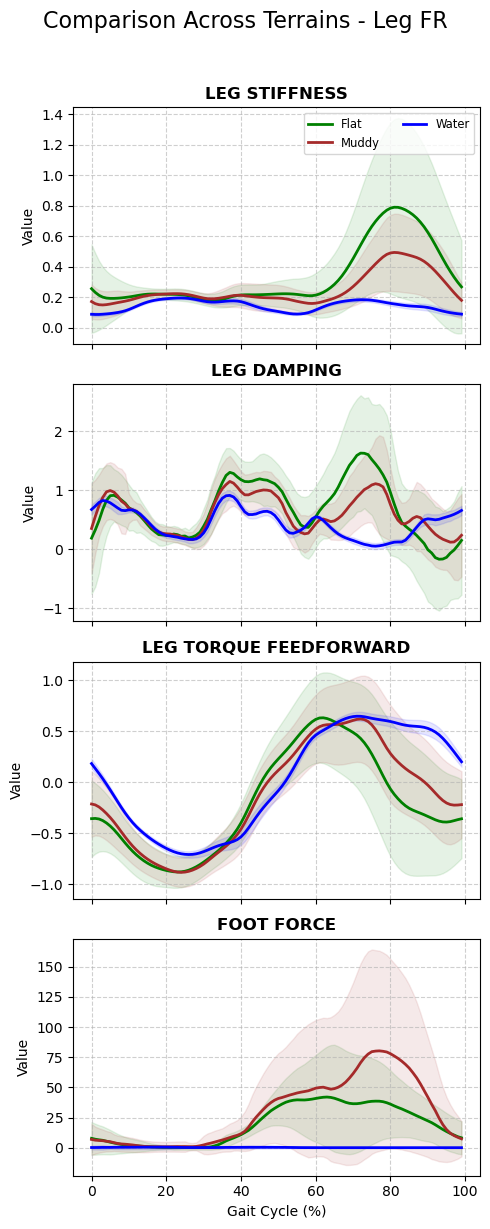

In [7]:
# List the sensors you want to visualize from the loaded file
sensors_to_plot = [
    'leg_stiffness', 
    'leg_damping', 
    'leg_torque_feedforward', 
    'foot_force'
]

# Use your previous subplot function
# Ensure name_legs is defined in your current environment
plot_all_sensors_comparison(
    dataset, 
    sensors_to_plot, 
    feature_index=0, 
    feature_name=f"Leg {name_legs[0]}"
)

# Pre Process Data

In [8]:
import numpy as np
import random

def split_gait_dataset(dataset, train_ratio=0.8, seed=42):
    """
    Splits the gait cycle dataset into training and testing sets.
    Safely handles sensors with mismatched cycle counts.
    """
    random.seed(seed)
    train_set = {}
    test_set = {}

    for terrain in dataset.keys():
        # 1. FIND THE MINIMUM CYCLE COUNT ACROSS ALL SENSORS
        # This ensures we don't try to access an index that doesn't exist for a sensor
        sensor_counts = [len(dataset[terrain][s]) for s in dataset[terrain].keys()]
        if not sensor_counts:
            continue
            
        min_cycles = min(sensor_counts)
        
        # 2. Generate indices based on the shortest sensor stream
        indices = list(range(min_cycles))
        random.shuffle(indices)
        
        split_idx = int(min_cycles * train_ratio)
        train_indices = indices[:split_idx]
        test_indices = indices[split_idx:]
        
        train_set[terrain] = {}
        test_set[terrain] = {}

        # 3. Distribute cycles
        for sensor in dataset[terrain].keys():
            all_cycles = dataset[terrain][sensor]
            # We only take the cycles up to min_cycles to stay synchronized
            train_set[terrain][sensor] = [all_cycles[i] for i in train_indices]
            test_set[terrain][sensor] = [all_cycles[i] for i in test_indices]
            
        print(f"Terrain {terrain.upper()}: Used {min_cycles} synchronized cycles. "
              f"({len(train_indices)} train, {len(test_indices)} test)")

    return train_set, test_set

# --- Execution ---
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.3)

Terrain FLAT: Used 62 synchronized cycles. (18 train, 44 test)
Terrain MUDDY: Used 59 synchronized cycles. (17 train, 42 test)
Terrain WATER: Used 53 synchronized cycles. (15 train, 38 test)


In [9]:
def format_for_esn(dataset_dict, terrain_to_id_map, sensor_order):
    """
    Converts the nested dictionary into flat X and y lists for the ESN.
    
    dataset_dict: The output from your split_gait_dataset function.
    terrain_to_id_map: Dictionary mapping string terrain names to integers (e.g., {'concrete': 0, 'grass': 1}).
    sensor_order: A strict list of sensor dictionary keys to ensure columns are always in the same order.
    """
    X_formatted = []
    y_formatted = []
    
    for terrain, sensors_data in dataset_dict.items():
        if terrain not in terrain_to_id_map:
            continue # Skip terrains we aren't training on
            
        label = terrain_to_id_map[terrain]
        
        # Get the number of cycles for this terrain (they are synchronized)
        n_cycles = len(sensors_data[sensor_order[0]])
        
        for i in range(n_cycles):
            # For cycle 'i', gather data from all 16 joints (K, D, tau)
            cycle_columns = []
            for sensor_name in sensor_order:
                # Ensure it's a numpy array
                sensor_array = np.array(sensors_data[sensor_name][i])
                
                # If the sensor data is 1D (e.g., shape (90,)), reshape to (90, 1) so it stacks horizontally
                if len(sensor_array.shape) == 1:
                    sensor_array = sensor_array.reshape(-1, 1)
                    
                cycle_columns.append(sensor_array)
            
            # Stack all sensors horizontally to create the (90 timesteps x 48 features) matrix
            full_gait_matrix = np.hstack(cycle_columns)
            
            X_formatted.append(full_gait_matrix)
            y_formatted.append(label)
            
    return X_formatted, np.array(y_formatted)

# Setup Dataset

In [10]:
# --- 1. Define your mappings to enforce consistency ---
# Assign an integer to each surface
TERRAIN_LABELS = {
    'flat': 0,
    'muddy': 1,
    'water': 2
}

# Define the STRICT order of your sensors. 
# (Replace these with the actual keys used in your dataset dictionary)
# Example: ['joint_1_K', 'joint_1_D', 'joint_1_tau', 'joint_2_K'...]
SENSOR_KEYS = list(dataset['flat'].keys()) 
# SENSOR_KEYS = ['joint_stiffness_fb', 'joint_damping_fb', 'joint_torque_ff_fb']
SENSOR_KEYS = ['leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
# SENSOR_KEYS = ['joint_torque_fb']
# SENSOR_KEYS = ['joint_torque_fb', 'foot_force']
# SENSOR_KEYS = ['foot_force']


print(SENSOR_KEYS)
# --- 2. Split the raw dataset ---
print("Splitting dataset...")
train_data, test_data = split_gait_dataset(dataset, train_ratio=0.5, seed=42)

# --- 3. Format for the ESN ---
print("\nFormatting data for ESN...")
X_train, y_train = format_for_esn(train_data, TERRAIN_LABELS, SENSOR_KEYS)
X_test, y_test = format_for_esn(test_data, TERRAIN_LABELS, SENSOR_KEYS)

print(f"Total Training Cycles: {len(X_train)}")
print(f"Total Testing Cycles: {len(X_test)}")
print(f"Input Matrix Shape: {X_train[0].shape}") # Should be roughly (90, 48)

['leg_stiffness', 'leg_damping', 'leg_torque_feedforward']
Splitting dataset...
Terrain FLAT: Used 62 synchronized cycles. (31 train, 31 test)
Terrain MUDDY: Used 59 synchronized cycles. (29 train, 30 test)
Terrain WATER: Used 53 synchronized cycles. (26 train, 27 test)

Formatting data for ESN...
Total Training Cycles: 86
Total Testing Cycles: 88
Input Matrix Shape: (100, 12)


# Grid Search

In [11]:
import numpy as np
import itertools
from scipy import stats
from env_pred import UnsupervisedESN  # Make sure this points to the new class!

# --- 1. Define the Hyperparameter Grid ---
print("\nSetting up Unsupervised Hyperparameter Grid Search...")

param_grid = {
    'n_reservoir': [50, 100, 200, 500, 1000], 
    'leak_rate': [0.1, 0.3, 0.5, 0.8],
    'spectral_radius': [0.8, 0.9, 0.95],
    'max_node': [10, 20, 30],
    'epoch': [10, 30, 50]
}

keys = param_grid.keys()
combinations = list(itertools.product(*param_grid.values()))

best_accuracy = 0.0
best_params = None
best_model = None
best_node_map = None

# --- 2. Run the Search ---
for i, values in enumerate(combinations):
    params = dict(zip(keys, values))
    
    print(f"\n[{i+1}/{len(combinations)}] Testing: res={params['n_reservoir']}, leak={params['leak_rate']}, sr={params['spectral_radius']}")
    
    model = UnsupervisedESN(
        n_reservoir=params['n_reservoir'], 
        leak_rate=params['leak_rate'], 
        spectral_radius=params['spectral_radius'],
        max_nodes=params['max_node']
    )
    
    # A. TRAIN THE MODEL 
    model.fit(X_train, epochs=params['epoch'])
    
    # B. CREATE THE NODE-TO-LABEL MAP (Post-Hoc Labeling)
    # 🚨 FIXED: Using .current_nodes instead of len(.nodes) 🚨
    node_assignments = {node_idx: [] for node_idx in range(model.gng_map.current_nodes)}
    
    for j in range(len(X_train)):
        node_id = model.predict(X_train[j])
        true_label = y_train[j]
        node_assignments[node_id].append(true_label)
        
    node_to_label_map = {}
    for node_id, labels_in_node in node_assignments.items():
        if len(labels_in_node) > 0:
            majority_label = stats.mode(labels_in_node, keepdims=False).mode
            # For older scipy versions, you might need stats.mode(...)[0][0]
            if isinstance(majority_label, np.ndarray):
                majority_label = majority_label[0]
            node_to_label_map[node_id] = majority_label
        else:
            node_to_label_map[node_id] = -1 

    # C. EVALUATE ON TEST SET
    correct = 0
    for j in range(len(X_test)):
        predicted_node = model.predict(X_test[j])
        translated_label = node_to_label_map.get(predicted_node, -1)
        
        if translated_label == y_test[j]:
            correct += 1
            
    accuracy = (correct / len(X_test)) * 100
    
    # 🚨 FIXED: Using .current_nodes for the print statement 🚨
    print(f"  -> Discovered {model.gng_map.current_nodes} Terrains | Test Accuracy: {accuracy:.2f}%")
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_params = params
        best_model = model  
        best_node_map = node_to_label_map 

# --- 3. Report and Save ---
print("\n" + "="*40)
print(f"🏆 BEST UNSUPERVISED BRAIN FOUND 🏆")
print(f"Accuracy: {best_accuracy:.2f}%")
print("Parameters:")
for k, v in best_params.items():
    print(f" - {k}: {v}")
print("\nTranslation Map (Node ID -> Terrain Label):")
print(best_node_map)
print("="*40 + "\n")

# Save the physical model parameters
best_model.save_model("env_pred_unsupervised_best.npz")


Setting up Unsupervised Hyperparameter Grid Search...

[1/540] Testing: res=50, leak=0.1, sr=0.8
1. ESN compressing 86 raw gait cycles...
2. MiniGNG mapping the topological space...
Training Complete! The MiniGNG dynamically grew 10 distinct terrain nodes.
  -> Discovered 10 Terrains | Test Accuracy: 82.95%

[2/540] Testing: res=50, leak=0.1, sr=0.8
1. ESN compressing 86 raw gait cycles...
2. MiniGNG mapping the topological space...
Training Complete! The MiniGNG dynamically grew 10 distinct terrain nodes.
  -> Discovered 10 Terrains | Test Accuracy: 84.09%

[3/540] Testing: res=50, leak=0.1, sr=0.8
1. ESN compressing 86 raw gait cycles...
2. MiniGNG mapping the topological space...
Training Complete! The MiniGNG dynamically grew 10 distinct terrain nodes.
  -> Discovered 10 Terrains | Test Accuracy: 86.36%

[4/540] Testing: res=50, leak=0.1, sr=0.8
1. ESN compressing 86 raw gait cycles...
2. MiniGNG mapping the topological space...
Training Complete! The MiniGNG dynamically grew 10 d

In [19]:
print(best_node_map)

{0: 2, 1: 1, 2: 1, 3: 0, 4: 1, 5: 0, 6: 0, 7: 0, 8: 0, 9: 1}


Booting up Unsupervised ESN Controller...

[SUCCESS] Unsupervised Brain loaded from: 'env_pred_unsupervised_best.npz'
----------------------------------------
💡 Hyperparameters:
   • Reservoir Size: 500 neurons
   • Leak Rate:      0.8
   • Discovered Terrains (GNG Nodes): 10
   • Maximum Nodes (GNG Nodes): 10.0
   • Number of Epoch (GNG): 30.0

⚙️ Matrix Shapes:
   • W_in  (Input -> Reservoir): (500, 12)
   • W_res (Reservoir Dynamics): (500, 500)
   • GNG Map (Nodes x Features): (10, 500)
----------------------------------------


Evaluating on unseen Test Set...
Test Accuracy: 95.45%


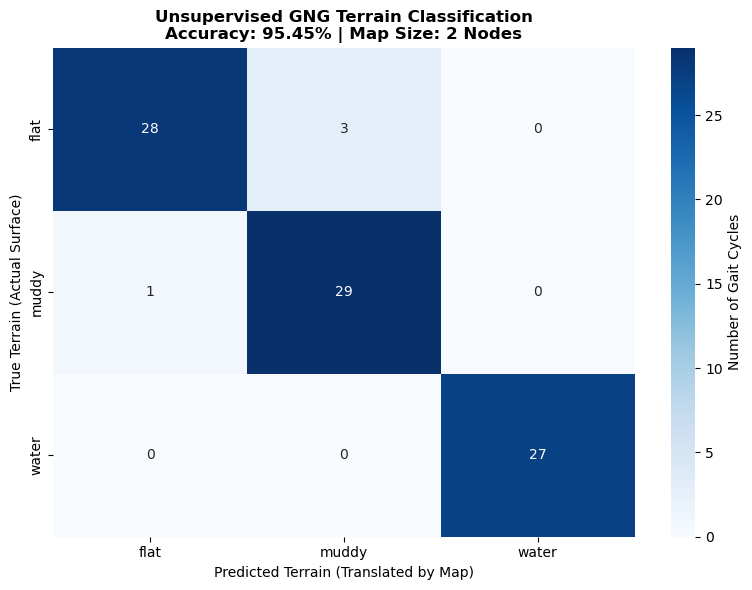

In [20]:
import numpy as np
from env_pred import UnsupervisedESN  # Make sure this points to the new class!
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# ==========================================
# 1. LOAD THE MODEL
# ==========================================
print("Booting up Unsupervised ESN Controller...")

model = UnsupervisedESN()

# Load the weights from the Unsupervised Grid Search
MODEL_FILENAME = "env_pred_unsupervised_best.npz" 
model.load_model(MODEL_FILENAME)

# ==========================================
# 2. DEFINE YOUR MAPPINGS
# ==========================================
TERRAIN_LABELS = {'flat': 0, 'muddy': 1, 'water': 2}

# 🚨 THE CRITICAL BRIDGE 🚨
# You MUST copy-paste the output dictionary that printed at the very end 
# of your Grid Search script into this variable!
# (This is just an example of what it might look like)
NODE_TO_TERRAIN_MAP = {0: 2, 1: 1, 2: 1, 3: 0, 4: 1, 5: 0, 6: 0, 7: 0, 8: 0, 9: 1}


# ==========================================
# 3. EVALUATE ON THE TEST SET
# ==========================================
print("\nEvaluating on unseen Test Set...")
y_pred_translated = []

for i in range(len(X_test)):
    # 1. Ask the GNG which Node we are in
    predicted_node = model.predict(X_test[i])
    
    # 2. Translate that Node ID into a physical Terrain ID
    # If it predicts a node we haven't mapped, default to -1 (Unknown)
    translated_class = NODE_TO_TERRAIN_MAP.get(predicted_node, -1)
    
    y_pred_translated.append(translated_class)

# Convert to numpy array for fast comparison
y_pred_translated = np.array(y_pred_translated)

# Calculate Accuracy (Only comparing valid terrain labels)
correct = np.sum(y_pred_translated == y_test)
accuracy = (correct / len(X_test)) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

# ==========================================
# 4. PLOT CONFUSION MATRIX
# ==========================================
# We use labels=[0,1,2] to ensure the matrix stays 3x3 even if some classes are missing
cm = confusion_matrix(y_test, y_pred_translated, labels=[0, 1, 2])

# Extract terrain names in the correct ID order (0, 1, 2)
terrain_names = [k for k, v in sorted(TERRAIN_LABELS.items(), key=lambda item: item[1])]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=terrain_names, 
            yticklabels=terrain_names,
            cbar_kws={'label': 'Number of Gait Cycles'})

# Updated title to reflect the unsupervised nature and node count
plt.title(f'Unsupervised GNG Terrain Classification\nAccuracy: {accuracy:.2f}% | Map Size: {model.gng_map.current_nodes} Nodes', fontweight='bold')
plt.ylabel('True Terrain (Actual Surface)')
plt.xlabel('Predicted Terrain (Translated by Map)')
plt.tight_layout()
plt.show()

## Visualzation

1. ESN compressing 86 raw gait cycles...
2. MiniGNG mapping the topological space...
Training Complete! The MiniGNG dynamically grew 10 distinct terrain nodes.
1. Building the Node-to-Terrain Translation Map...
Running 88 steps through the Unsupervised Brain...
🏆 Final Test Accuracy: 95.45%


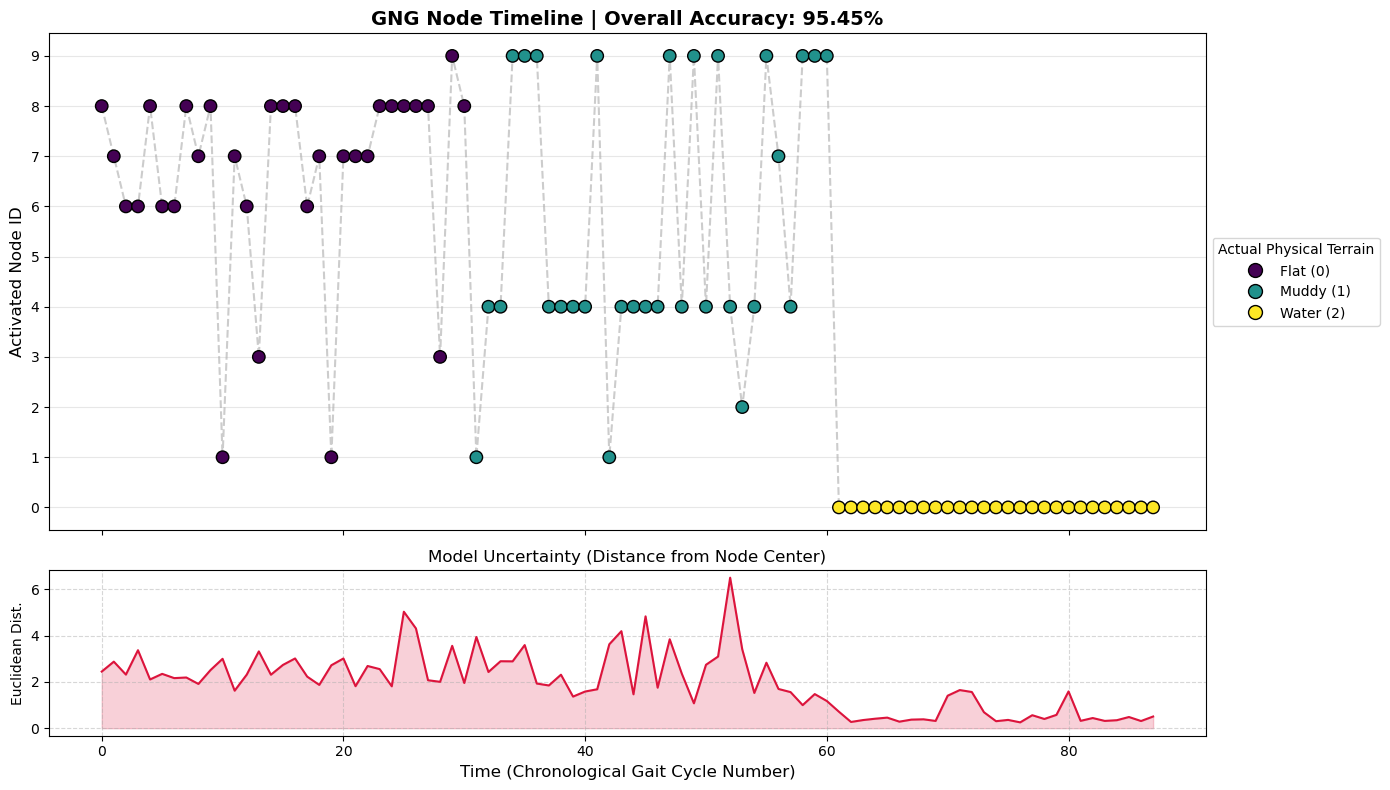

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import matplotlib.lines as mlines

def evaluate_and_plot_timeline(model, X_train, y_train, X_test, y_test):
    """
    Calculates Accuracy, computes Uncertainty (Distance), and visualizes the timeline.
    """
    print("1. Building the Node-to-Terrain Translation Map...")
    # Map each node using the Training Data majority vote
    node_assignments = {i: [] for i in range(model.gng_map.current_nodes)}
    for j in range(len(X_train)):
        node_id = model.predict(X_train[j])
        node_assignments[node_id].append(y_train[j])
        
    translation_map = {}
    for node_id, labels in node_assignments.items():
        if len(labels) > 0:
            majority = stats.mode(labels, keepdims=False).mode
            translation_map[node_id] = majority if not isinstance(majority, np.ndarray) else majority[0]
        else:
            translation_map[node_id] = -1

    print(f"Running {len(X_test)} steps through the Unsupervised Brain...")
    
    predicted_nodes = []
    translated_terrains = []
    uncertainties = [] # This will store our distance metrics
    
    # Get the GNG nodes array for distance calculations
    gng_weights = model.gng_map.get_nodes
    
    correct_predictions = 0
    
    for i, cycle in enumerate(X_test):
        # 1. Get the raw node ID
        node_id = model.predict(cycle)
        predicted_nodes.append(node_id)
        
        # 2. Translate to Terrain ID and Check Accuracy
        terrain_id = translation_map.get(node_id, -1)
        translated_terrains.append(terrain_id)
        if terrain_id == y_test[i]:
            correct_predictions += 1
            
        # 3. Calculate Uncertainty (Distance to the winning node)
        # We manually extract the vector to measure how far it is from the node center
        v = model._get_reservoir_photograph(cycle)
        winning_node_center = gng_weights[node_id]
        distance = np.linalg.norm(v - winning_node_center)
        uncertainties.append(distance)
        
    accuracy = (correct_predictions / len(X_test)) * 100
    print(f"🏆 Final Test Accuracy: {accuracy:.2f}%")

    # --- VISUALIZATION ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    # TOP PLOT: The Node Timeline
    ax1.plot(range(len(X_test)), predicted_nodes, color='gray', linestyle='--', alpha=0.4, zorder=1)
    scatter = ax1.scatter(range(len(X_test)), predicted_nodes, 
                          c=y_test, cmap='viridis', 
                          s=80, edgecolor='black', zorder=2)
    
# --- NEW LEGEND LOGIC ---
    cmap = plt.cm.get_cmap('viridis')
    # Create custom legend markers using the exact colors from the viridis map (0.0, 0.5, and 1.0)
    legend_handles = [
        mlines.Line2D([], [], color='w', marker='o', markerfacecolor=cmap(0.0), markersize=10, markeredgecolor='black', label='Flat (0)'),
        mlines.Line2D([], [], color='w', marker='o', markerfacecolor=cmap(0.5), markersize=10, markeredgecolor='black', label='Muddy (1)'),
        mlines.Line2D([], [], color='w', marker='o', markerfacecolor=cmap(1.0), markersize=10, markeredgecolor='black', label='Water (2)')
    ]
    
    # Add the legend to the top plot, placed outside or in a corner so it doesn't block the data
    ax1.legend(handles=legend_handles, title='Actual Physical Terrain', loc='center left', bbox_to_anchor=(1, 0.5), frameon=True)
    # ------------------------
    
    ax1.set_title(f'GNG Node Timeline | Overall Accuracy: {accuracy:.2f}%', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Activated Node ID', fontsize=12)
    ax1.set_yticks(range(model.gng_map.current_nodes))
    ax1.grid(True, axis='y', linestyle='-', alpha=0.3)
    
    # BOTTOM PLOT: Uncertainty / Anomaly Metric
    ax2.plot(range(len(X_test)), uncertainties, color='crimson', linewidth=1.5)
    ax2.fill_between(range(len(X_test)), uncertainties, color='crimson', alpha=0.2)
    
    ax2.set_title('Model Uncertainty (Distance from Node Center)', fontsize=12)
    ax2.set_xlabel('Time (Chronological Gait Cycle Number)', fontsize=12)
    ax2.set_ylabel('Euclidean Dist.', fontsize=10)
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# RUN
# ==========================================

model = UnsupervisedESN(n_reservoir=500, leak_rate=0.8, max_nodes=10, spectral_radius=0.95)
model.fit(X_train, epochs=30)
evaluate_and_plot_timeline(model, X_train, y_train, X_test, y_test)

1. Compressing raw steps through the ESN...
2. Retrieving the GNG Map...
3. Running t-SNE Dimensionality Reduction (Squashing 100D -> 2D)...


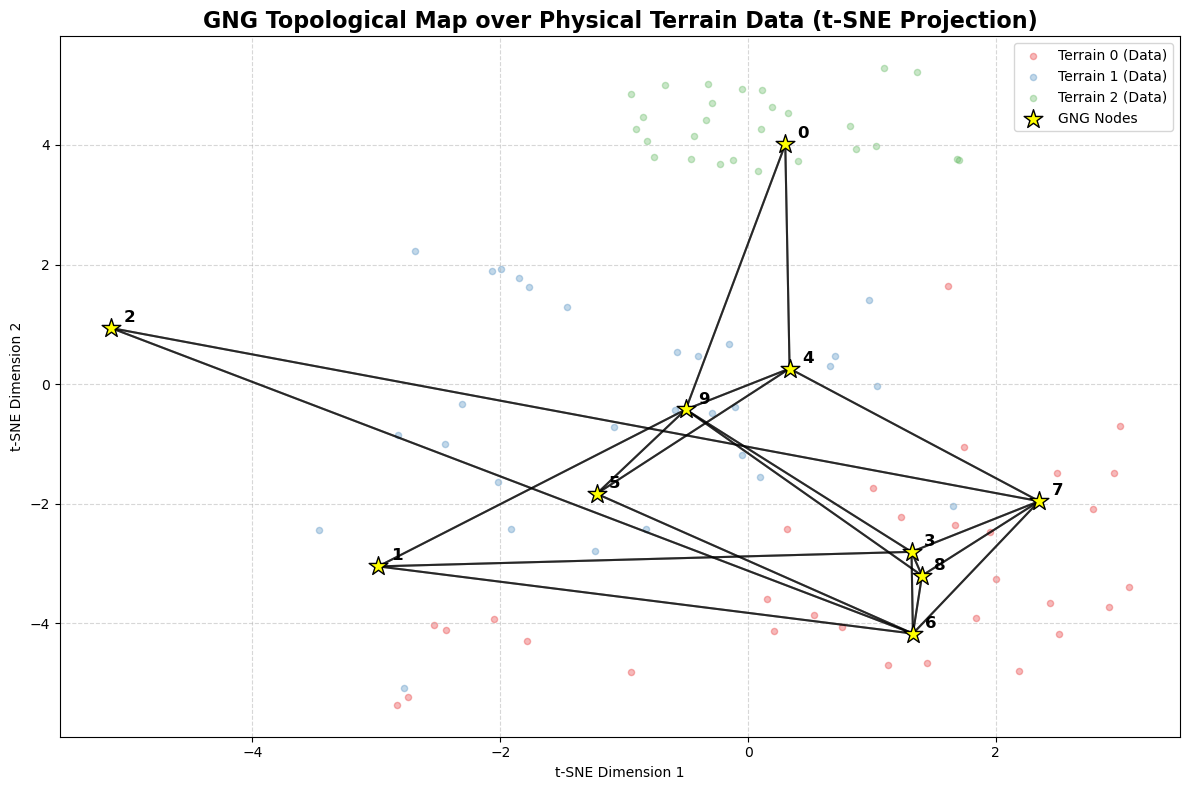

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import seaborn as sns

def visualize_gng_map(model, X_raw, y_true):
    """
    Squashes the 100D ESN vectors and the GNG nodes into 2D using t-SNE,
    and draws the topological web over the raw data clusters.
    """
    print("1. Compressing raw steps through the ESN...")
    X_compressed = np.array([model._get_reservoir_photograph(cycle) for cycle in X_raw])
    
    print("2. Retrieving the GNG Map...")
    # Get the 100D coordinates of the nodes
    nodes_100d = model.gng_map.get_nodes
    
    # We combine the raw data AND the nodes so t-SNE projects them onto the same 2D canvas
    combined_100d = np.vstack([X_compressed, nodes_100d])
    
    print("3. Running t-SNE Dimensionality Reduction (Squashing 100D -> 2D)...")
    # You can swap TSNE for UMAP here if you have umap-learn installed!
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    combined_2d = tsne.fit_transform(combined_100d)
    
    # Split the 2D data back apart
    X_2d = combined_2d[:len(X_compressed)]
    nodes_2d = combined_2d[len(X_compressed):]
    
    # --- PLOTTING ---
    plt.figure(figsize=(12, 8))
    
    # 1. Plot the raw data points, colored by their True Terrain
    # Using a distinct palette (e.g., Flat=Blue, Muddy=Orange, Water=Green)
    palette = sns.color_palette("Set1", n_colors=len(np.unique(y_true)))
    for label_id in np.unique(y_true):
        idx = np.where(y_true == label_id)[0]
        plt.scatter(X_2d[idx, 0], X_2d[idx, 1], 
                    label=f'Terrain {label_id} (Data)', 
                    color=palette[label_id], alpha=0.3, s=20)
        
    # 2. Draw the GNG Edges (The Topological Web)
    # We have to map the active nodes back to their original array indices to read the edges matrix
    active_idx = np.where(model.gng_map.active)[0]
    
    # Draw lines between nodes that share an edge
    for k1, idx1 in enumerate(active_idx):
        for k2, idx2 in enumerate(active_idx):
            # If an edge exists (-1 means no edge)
            if model.gng_map.edges[idx1, idx2] != -1:
                plt.plot([nodes_2d[k1, 0], nodes_2d[k2, 0]], 
                         [nodes_2d[k1, 1], nodes_2d[k2, 1]], 
                         'k-', linewidth=1.5, alpha=0.6, zorder=3)
                
    # 3. Plot the GNG Nodes on top of the web
    plt.scatter(nodes_2d[:, 0], nodes_2d[:, 1], 
                c='yellow', edgecolors='black', s=200, marker='*', 
                label='GNG Nodes', zorder=4)
    
    # Number the nodes so you can cross-reference your Translation Map!
    for i in range(len(nodes_2d)):
        plt.annotate(str(i), (nodes_2d[i, 0] + 0.1, nodes_2d[i, 1] + 0.1), 
                     fontsize=12, fontweight='bold', zorder=5)

    plt.title("GNG Topological Map over Physical Terrain Data (t-SNE Projection)", fontsize=16, fontweight='bold')
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

# ==========================================
# HOW TO RUN IT
# ==========================================
# Assuming you have your fully trained UnsupervisedESN model loaded
visualize_gng_map(model, X_test, y_test)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from sklearn.decomposition import PCA
import seaborn as sns
from IPython.display import HTML

def animate_gng_training(model_empty, X_raw, y_true, total_epochs=50):
    print("1. Compressing raw steps through the ESN...")
    # Get the 100D vectors
    X_compressed = np.array([model_empty._get_reservoir_photograph(cycle) for cycle in X_raw])
    
    print("2. Creating a fixed 2D canvas using PCA...")
    # Fit PCA on the data to lock the background in place
    pca = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_compressed)
    
    print(f"3. Training GNG and capturing {total_epochs} frames...")
    frames_data = []
    
    # Train epoch by epoch and capture the state of the web
    for epoch in range(total_epochs):
        # Train for exactly 1 epoch
        model_empty.gng_map.train(X_compressed, epochs=1)
        
        # Capture the current absolute positions and connections
        active_idx = np.where(model_empty.gng_map.active)[0]
        weights_100d = model_empty.gng_map.weights[active_idx]
        
        # Project the nodes into the locked PCA space
        nodes_2d = pca.transform(weights_100d) if len(weights_100d) > 0 else []
        
        # Save a copy of the edges for this frame
        edges = model_empty.gng_map.edges.copy()
        
        frames_data.append({
            'epoch': epoch + 1,
            'active_idx': active_idx,
            'nodes_2d': nodes_2d,
            'edges': edges
        })
        
    print("4. Rendering Animation...")
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Plot the static background data
    palette = sns.color_palette("Set1", n_colors=len(np.unique(y_true)))
    for label_id in np.unique(y_true):
        idx = np.where(y_true == label_id)[0]
        ax.scatter(X_2d[idx, 0], X_2d[idx, 1], 
                   label=f'Terrain {label_id}', color=palette[label_id], alpha=0.3, s=20)
    
    ax.legend(loc="lower right")
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Initialize empty graphical objects for the animation
    nodes_scatter = ax.scatter([], [], c='yellow', edgecolors='black', s=200, marker='*', zorder=4)
    lines_container = []
    title_text = ax.set_title("", fontsize=16, fontweight='bold')
    
    def update(frame_idx):
        # Clear old edges
        for line in lines_container:
            line.remove()
        lines_container.clear()
        
        frame = frames_data[frame_idx]
        nodes_2d = frame['nodes_2d']
        active_idx = frame['active_idx']
        edges = frame['edges']
        
        # Update Node positions
        if len(nodes_2d) > 0:
            nodes_scatter.set_offsets(nodes_2d)
            
            # Draw new edges
            # We map local index (k) back to absolute index to check the edges matrix
            for k1, idx1 in enumerate(active_idx):
                for k2, idx2 in enumerate(active_idx):
                    if edges[idx1, idx2] != -1:
                        line, = ax.plot([nodes_2d[k1, 0], nodes_2d[k2, 0]], 
                                        [nodes_2d[k1, 1], nodes_2d[k2, 1]], 
                                        'k-', linewidth=1.5, alpha=0.6, zorder=3)
                        lines_container.append(line)
                        
        title_text.set_text(f"GNG Web Growth (PCA) | Epoch: {frame['epoch']}/{total_epochs} | Nodes: {len(active_idx)}")
        return [nodes_scatter, title_text] + lines_container

    # Compile the animation
    anim = FuncAnimation(fig, update, frames=total_epochs, interval=200, blit=True)
    plt.close() # Prevents Jupyter from showing a static duplicate plot
    
    return anim

# ==========================================
# HOW TO RUN IT
# ==========================================
# 1. Initialize a BRAND NEW, completely empty model
fresh_model = UnsupervisedESN(n_reservoir=500, leak_rate=0.8, max_nodes=10, spectral_radius=0.95)
fresh_model._initialize_esn(X_train[0].shape[1])# Manually init ESN matrices before loop

# 2. Generate the animation object
my_animation = animate_gng_training(fresh_model, X_test, y_test, total_epochs=30)

# 3. Display it interactively inside Jupyter (HTML5 Video)
HTML(my_animation.to_jshtml())

# print("Saving animation as GIF... (This might take a few seconds)")
# # We set fps=5 to match the 200ms interval you used in the animation code (1000ms / 200ms = 5 frames per second)
# my_animation.save('gng_web_growth.gif', writer='pillow', fps=5)
# print("✅ Saved successfully as 'gng_web_growth.gif'!")

1. Compressing raw steps through the ESN...
2. Creating a fixed 2D canvas using PCA...
3. Training GNG and capturing 30 frames...
4. Rendering Animation...
Saving animation as GIF... (This might take a few seconds)
✅ Saved successfully as 'gng_web_growth.gif'!
